Options Price Modeling

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

Option Price Change

In [ ]:
### simple function for a rough estimate ###

def calc_opt_price_change(delta, gamma, theta, dS, days):
    dV=theta*days + delta*dS + (1/2)*gamma*dS**2
    return dV

In [4]:
### The Greeks ###

delta_1=-0.272
gamma_1=0.3777
theta_1=-0.0053 

In [5]:
dV=calc_opt_price_change(delta_1, gamma_1, theta_1, -1.02, 28)

In [6]:
current_price=0.15
num_contracts=2

print(f"Estimated Option Gain ${dV}")
print(f"Estimated Option Price ${dV+current_price}")
print(f"Estimated Credit = ${(current_price+dV)*num_contracts*100}")

Estimated Option Gain $0.32551954
Estimated Option Price $0.47551953999999996
Estimated Credit = $95.10390799999999


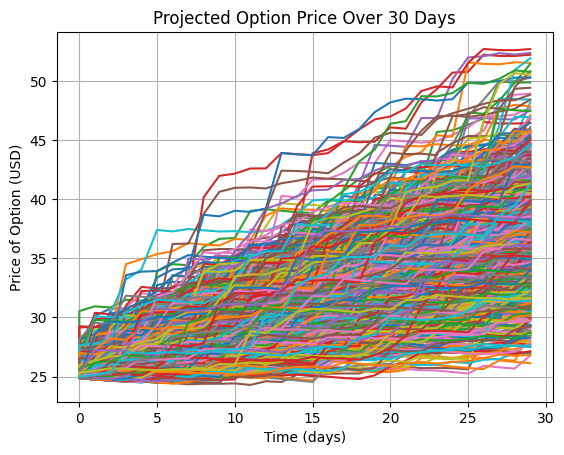

In [ ]:
### plug in ds to get dV

### Underlying Asset ###
shots=1000
time=30 # in days
dt=1/252 #1 day
s0=100
mu=0.10    # expected annual return
sigma=0.25 #annual votality

### Option ###
v0= 25
delta= 0.272
gamma= 0.3
theta= -0.0053



final_prices=[]
for shot in range(shots):
    s=s0
    v=v0
    days=[0]
    price=[v0]
    
    
    for i in range(time):
        z=np.random.normal(0, 1)
        ds=mu*s*dt + sigma*s*z*np.sqrt(dt)
        s+=ds
        dv=calc_opt_price_change(delta, gamma, theta, ds, 1)
        v+=dv
        days.append(i)
        price.append(v)
    plt.plot(days, price)
    plt.xlabel("Time (days)")
    plt.ylabel("Price of Option (USD)")
    plt.title(f"Projected Option Price Over {time} Days")
    plt.grid(True)
plt.show() 

Modeling (Check later)

In [3]:
def norm_cdf(x: float) -> float:
    # Standard normal CDF using erf (no scipy needed)
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def bs_analytic(S, K, T, r, sigma, option="call"):
    if T <= 0:
        return max(S - K, 0.0) if option == "call" else max(K - S, 0.0)
    if sigma <= 0:
        # Deterministic limit
        forward = S * math.exp(r * T)
        discK = K
        payoff = max(forward - discK, 0.0) if option == "call" else max(discK - forward, 0.0)
        return math.exp(-r * T) * payoff

    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    if option == "call":
        return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)
    else:
        return K * math.exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)

def thomas_solve(a, b, c, d):
    """
    Solve tridiagonal system:
      a[i]*x[i-1] + b[i]*x[i] + c[i]*x[i+1] = d[i]
    where a[0]=0 and c[-1]=0.
    """
    n = len(d)
    c_star = [0.0] * n
    d_star = [0.0] * n

    # Forward sweep
    denom = b[0]
    if abs(denom) < 1e-15:
        raise ValueError("Singular tridiagonal system (b[0] ~ 0).")
    c_star[0] = c[0] / denom
    d_star[0] = d[0] / denom

    for i in range(1, n):
        denom = b[i] - a[i] * c_star[i - 1]
        if abs(denom) < 1e-15:
            raise ValueError(f"Singular tridiagonal system at row {i}.")
        c_star[i] = c[i] / denom if i < n - 1 else 0.0
        d_star[i] = (d[i] - a[i] * d_star[i - 1]) / denom

    # Back substitution
    x = [0.0] * n
    x[-1] = d_star[-1]
    for i in range(n - 2, -1, -1):
        x[i] = d_star[i] - c_star[i] * x[i + 1]
    return x

def black_scholes_pde_cn(
    S0: float,
    K: float,
    T: float,
    r: float,
    sigma: float,
    option: str = "call",
    Smax_mult: float = 5.0,
    M: int = 400,   # space steps (S grid has M+1 points)
    N: int = 400    # time steps
):
    """
    Crank–Nicolson finite difference solver for Black–Scholes PDE.
    Returns (price_at_S0, S_grid, V_grid_at_t0).
    """
    if option not in ("call", "put"):
        raise ValueError("option must be 'call' or 'put'")
    if T <= 0:
        payoff = max(S0 - K, 0.0) if option == "call" else max(K - S0, 0.0)
        return payoff, [S0], [payoff]

    # Grid in S
    Smax = max(S0, K) * Smax_mult
    dS = Smax / M
    S = [i * dS for i in range(M + 1)]

    # Time step (backward from T to 0)
    dt = T / N

    # Terminal payoff V(S, T)
    if option == "call":
        V = [max(s - K, 0.0) for s in S]
    else:
        V = [max(K - s, 0.0) for s in S]

    # Precompute coefficients for interior nodes i=1..M-1
    # Using standard CN discretization on uniform S-grid.
    # Define:
    # alpha_i = 0.25*dt*(sigma^2*i^2 - r*i)
    # beta_i  = -0.5*dt*(sigma^2*i^2 + r)
    # gamma_i = 0.25*dt*(sigma^2*i^2 + r*i)
    # where i corresponds to S_i = i*dS (since S is linear in i).
    alpha = [0.0] * (M + 1)
    beta  = [0.0] * (M + 1)
    gamma = [0.0] * (M + 1)

    for i in range(1, M):
        ii = float(i)
        alpha[i] = 0.25 * dt * (sigma * sigma * ii * ii - r * ii)
        beta[i]  = -0.5 * dt * (sigma * sigma * ii * ii + r)
        gamma[i] = 0.25 * dt * (sigma * sigma * ii * ii + r * ii)

    # Step backward in time
    for n in range(N):
        t = T - n * dt  # current time level (going backward)

        # Boundary conditions at time (t - dt) after stepping:
        # For calls: V(0,t)=0, V(Smax,t)=Smax - K*exp(-r*(T-t))
        # For puts : V(0,t)=K*exp(-r*(T-t)), V(Smax,t)=0
        tau_next = T - (t - dt)  # time remaining after this step
        discK_next = K * math.exp(-r * tau_next)

        if option == "call":
            V_left  = 0.0
            V_right = Smax - discK_next
        else:
            V_left  = discK_next
            V_right = 0.0

        # Build RHS for interior nodes
        rhs = [0.0] * (M - 1)  # corresponds to i=1..M-1
        for i in range(1, M):
            rhs[i - 1] = (
                alpha[i] * V[i - 1] +
                (1.0 + beta[i]) * V[i] +
                gamma[i] * V[i + 1]
            )

        # Incorporate boundary contributions (from the implicit matrix side)
        # LHS for CN: -alpha_i * V_{i-1}^{new} + (1 - beta_i) * V_i^{new} - gamma_i * V_{i+1}^{new}
        # When i=1, V_{0}^{new} is boundary; when i=M-1, V_{M}^{new} is boundary.
        rhs[0]     += alpha[1] * V_left
        rhs[-1]    += gamma[M - 1] * V_right

        # Build tridiagonal LHS for interior nodes
        a = [0.0] * (M - 1)
        b = [0.0] * (M - 1)
        c = [0.0] * (M - 1)

        for i in range(1, M):
            idx = i - 1
            a[idx] = -alpha[i]              # sub-diagonal
            b[idx] = 1.0 - beta[i]          # main diagonal
            c[idx] = -gamma[i]              # super-diagonal

        a[0] = 0.0
        c[-1] = 0.0

        V_interior_new = thomas_solve(a, b, c, rhs)

        # Update full V with boundaries
        V_new = [0.0] * (M + 1)
        V_new[0] = V_left
        for i in range(1, M):
            V_new[i] = V_interior_new[i - 1]
        V_new[M] = V_right

        V = V_new

    # Interpolate price at S0
    if S0 <= 0:
        price = V[0]
    elif S0 >= Smax:
        price = V[-1]
    else:
        i = int(S0 / dS)
        w = (S0 - S[i]) / dS
        price = (1 - w) * V[i] + w * V[i + 1]

    return price, S, V

if __name__ == "__main__":
    # Example
    S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.2

    pde_call, Sgrid, V0 = black_scholes_pde_cn(S0, K, T, r, sigma, option="call", M=400, N=400)
    ana_call = bs_analytic(S0, K, T, r, sigma, option="call")

    print("Call (PDE CN):", pde_call)
    print("Call (Analytic):", ana_call)
    print("Abs error:", abs(pde_call - ana_call))

Call (PDE CN): 10.446722937754506
Call (Analytic): 10.450583572185565
Abs error: 0.0038606344310583296
